In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:

# 2. LOAD DATASET


file_path = "../data/diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (253680, 22)


In [3]:
# ============================================================
# 3. BASIC DATASET OVERVIEW
# ============================================================

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

First 5 rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 n

In [4]:
# ============================================================
# 4. MISSING VALUE CHECK
# ============================================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values in each column:


Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Total missing values: 0


In [5]:
# ============================================================
# 5. DUPLICATE CHECK
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 24206


In [6]:
# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

print("Duplicate rows:", df.duplicated().sum())

# Number of rows remaining after removing duplicates
df_no_duplicates = df.drop_duplicates()

print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_no_duplicates))
print("Rows removed:", len(df) - len(df_no_duplicates))

Duplicate rows: 24206
Rows before removing duplicates: 253680
Rows after removing duplicates: 229474
Rows removed: 24206


In [7]:
# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

target_counts = df["Diabetes_binary"].value_counts().sort_index()
target_percentages = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_distribution)

,Count,Percentage
Diabetes_binary,,
0.0,218334,86.07
1.0,35346,13.93


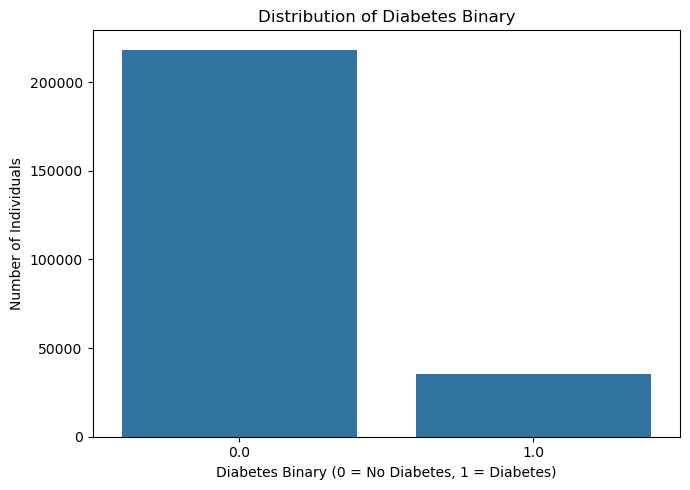

In [8]:
# Target distribution visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title("Distribution of Diabetes Binary")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 8. REMOVE DUPLICATE ROWS
# ============================================================

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

print(f"Rows removed: {253680 - len(df)}")

Shape before removing duplicates: (253680, 22)
Shape after removing duplicates: (229474, 22)
Rows removed: 24206


In [10]:
# ============================================================
# 9. VERIFY DATA CLEANING
# ============================================================

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Final dataset shape: (229474, 22)


In [11]:
# ============================================================
# 10. STATISTICAL SUMMARY
# ============================================================

pd.set_option("display.max_columns", None)

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,229474.0,0.152945,0.359936,0.0,0.0,0.0,0.0,1.0
HighBP,229474.0,0.454343,0.497912,0.0,0.0,0.0,1.0,1.0
HighChol,229474.0,0.441640,0.496584,0.0,0.0,0.0,1.0,1.0
CholCheck,229474.0,0.959481,0.197173,0.0,1.0,1.0,1.0,1.0
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0
Smoker,229474.0,0.465800,0.498830,0.0,0.0,0.0,1.0,1.0
Stroke,229474.0,0.044816,0.206899,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,229474.0,0.103336,0.304398,0.0,0.0,0.0,0.0,1.0
PhysActivity,229474.0,0.733042,0.442371,0.0,0.0,1.0,1.0,1.0
Fruits,229474.0,0.612675,0.487140,0.0,0.0,1.0,1.0,1.0


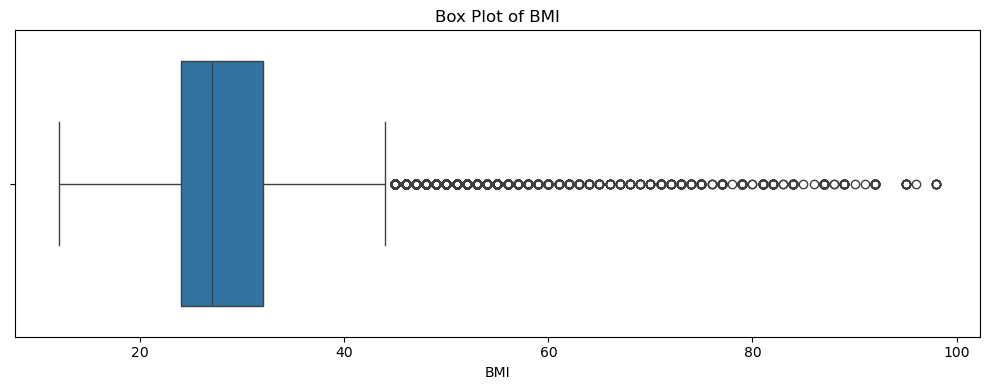

Minimum BMI: 12.0
Maximum BMI: 98.0
Mean BMI: 28.69
Median BMI: 27.0


In [12]:
# ============================================================
# 11. BMI OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["BMI"])

plt.title("Box Plot of BMI")
plt.xlabel("BMI")

plt.tight_layout()
plt.show()

print("Minimum BMI:", df["BMI"].min())
print("Maximum BMI:", df["BMI"].max())
print("Mean BMI:", round(df["BMI"].mean(), 2))
print("Median BMI:", df["BMI"].median())

In [13]:
# ============================================================
# 12. BMI IQR OUTLIER DETECTION
# ============================================================

Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

bmi_outliers = df[
    (df["BMI"] < lower_bound) |
    (df["BMI"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Potential BMI outliers:", len(bmi_outliers))
print(
    "Percentage of potential outliers:",
    round(len(bmi_outliers) / len(df) * 100, 2),
    "%"
)

Q1: 24.0
Q3: 32.0
IQR: 8.0
Lower bound: 12.0
Upper bound: 44.0
Potential BMI outliers: 5638
Percentage of potential outliers: 2.46 %


In [14]:
# ============================================================
# 13. FEATURE GROUPING
# ============================================================

binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

numeric_features = [
    "BMI",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income"
]

print("Number of binary features:", len(binary_features))
print("Number of numeric/ordinal features:", len(numeric_features))

Number of binary features: 14
Number of numeric/ordinal features: 7


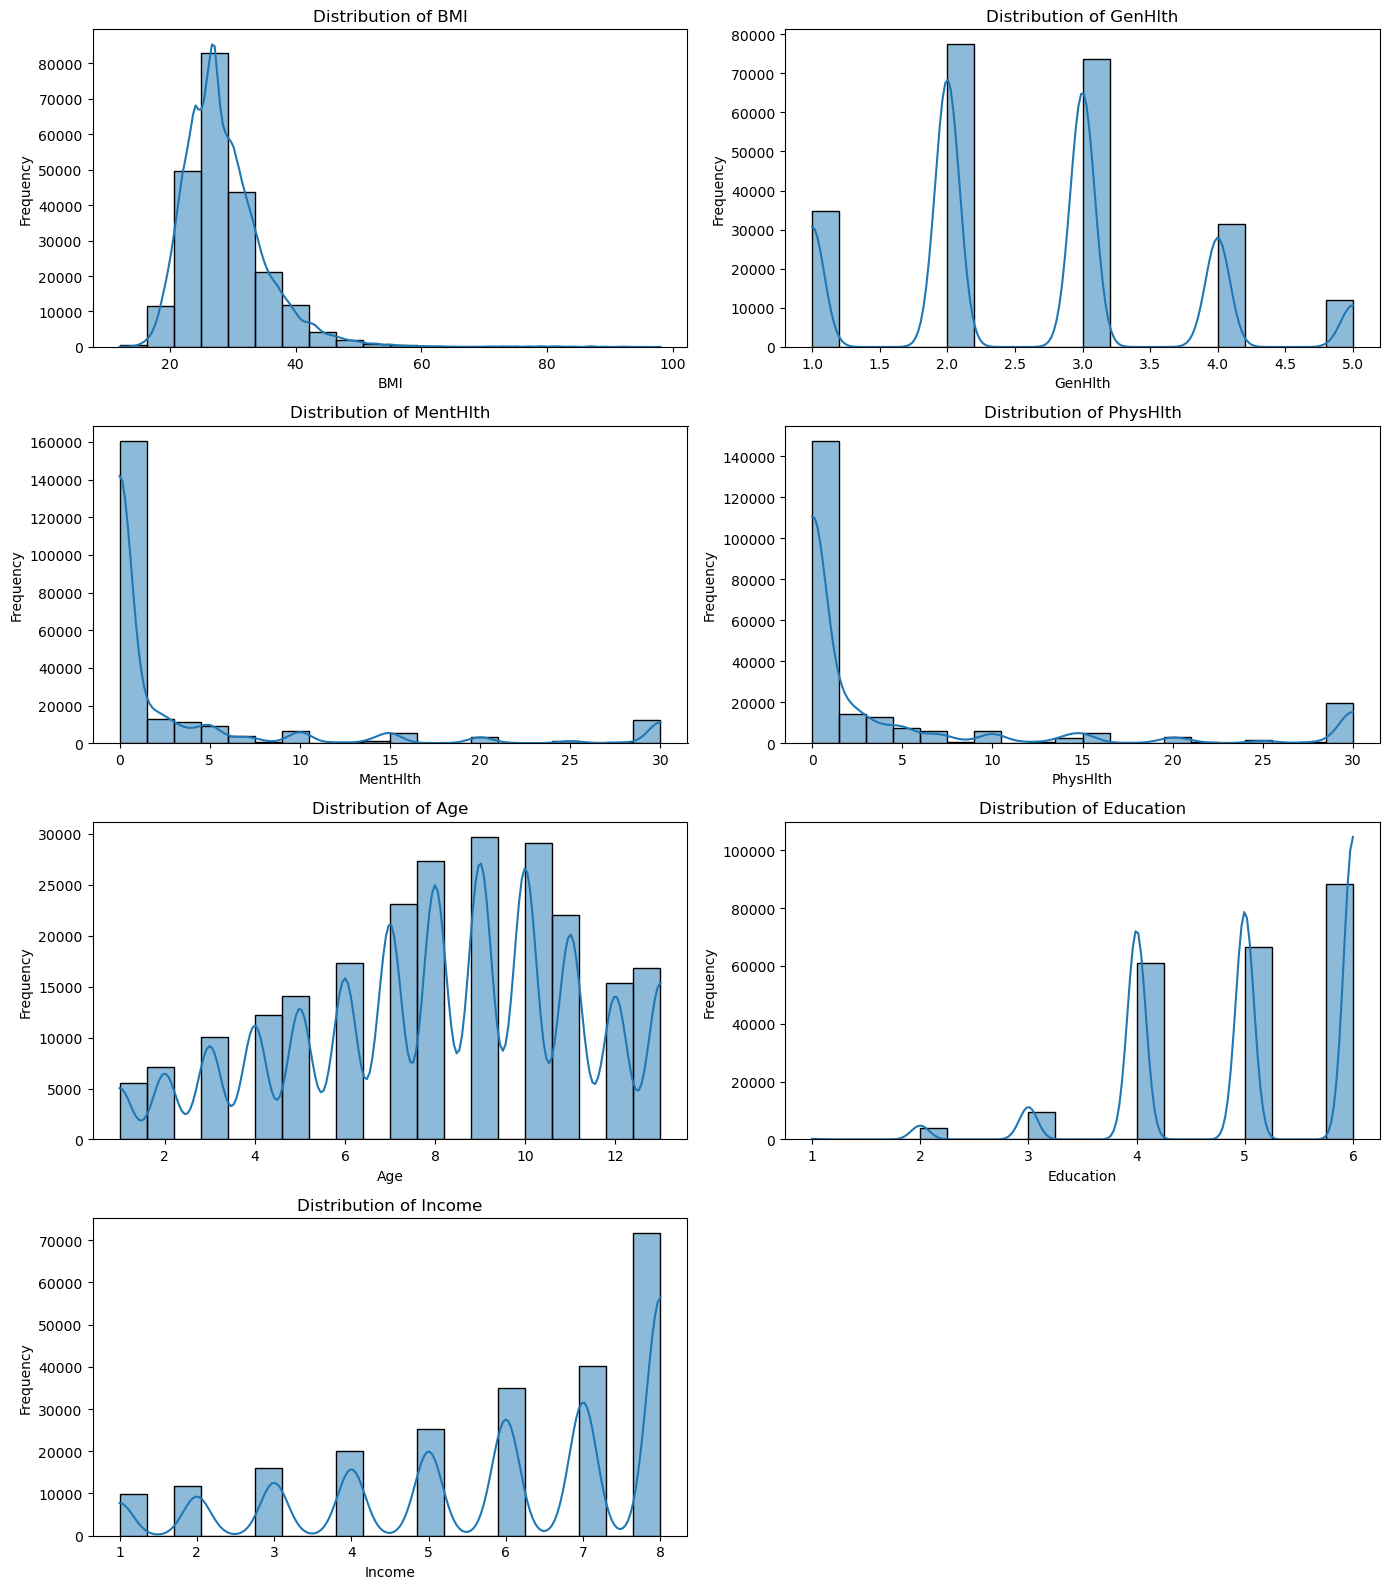

In [15]:
# ============================================================
# 14. DISTRIBUTION OF NUMERIC/ORDINAL FEATURES
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for ax, feature in zip(axes.flatten(), numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

# Hide unused subplot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

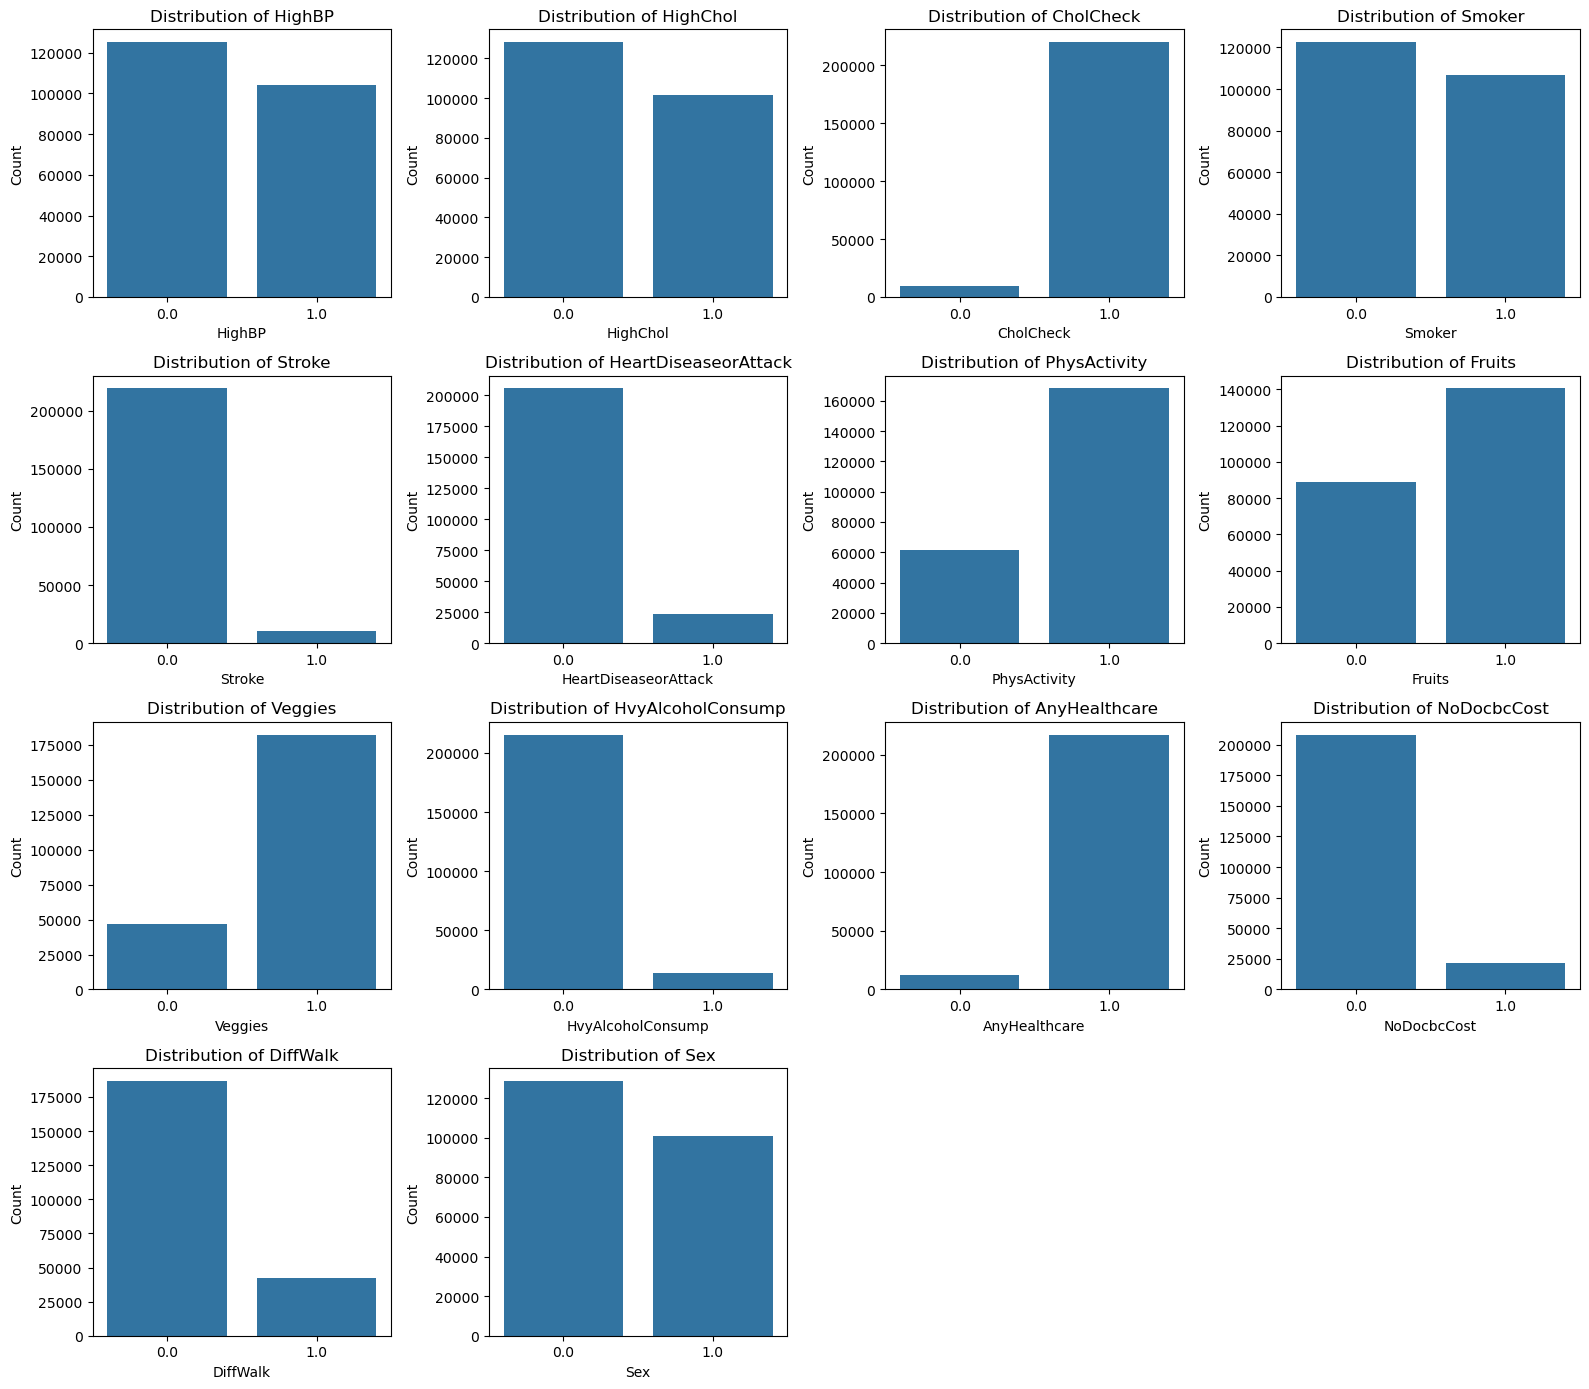

In [16]:
# ============================================================
# 15. DISTRIBUTION OF BINARY FEATURES
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for ax, feature in zip(axes.flatten(), binary_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

# Hide unused subplot
for ax in axes.flatten()[len(binary_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

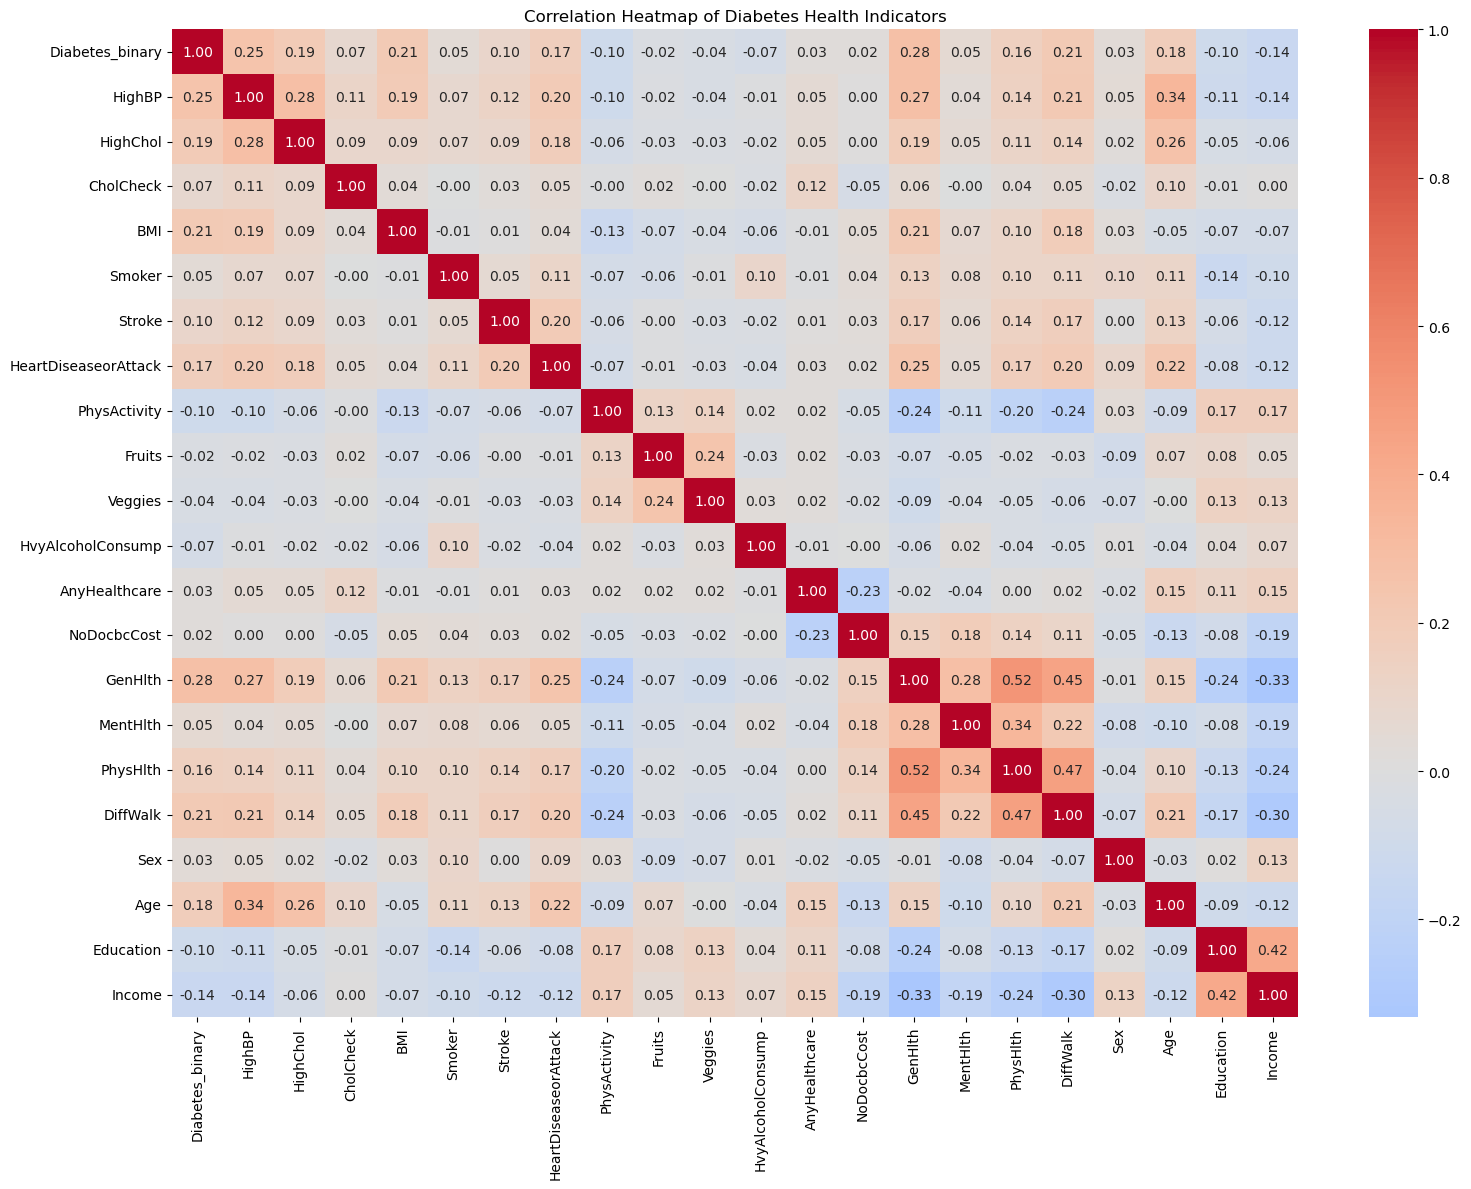

In [17]:
# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================

correlation_matrix = df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Diabetes Health Indicators")
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 17. FEATURE CORRELATION WITH TARGET
# ============================================================

target_correlations = (
    df.corr()["Diabetes_binary"]
    .drop("Diabetes_binary")
    .sort_values(ascending=False)
)

display(target_correlations.to_frame("Correlation with Diabetes_binary"))

,Correlation with Diabetes_binary
GenHlth,0.276940
HighBP,0.254318
DiffWalk,0.205302
BMI,0.205086
HighChol,0.194944
Age,0.177263
HeartDiseaseorAttack,0.168213
PhysHlth,0.156211
Stroke,0.099193
CholCheck,0.072523


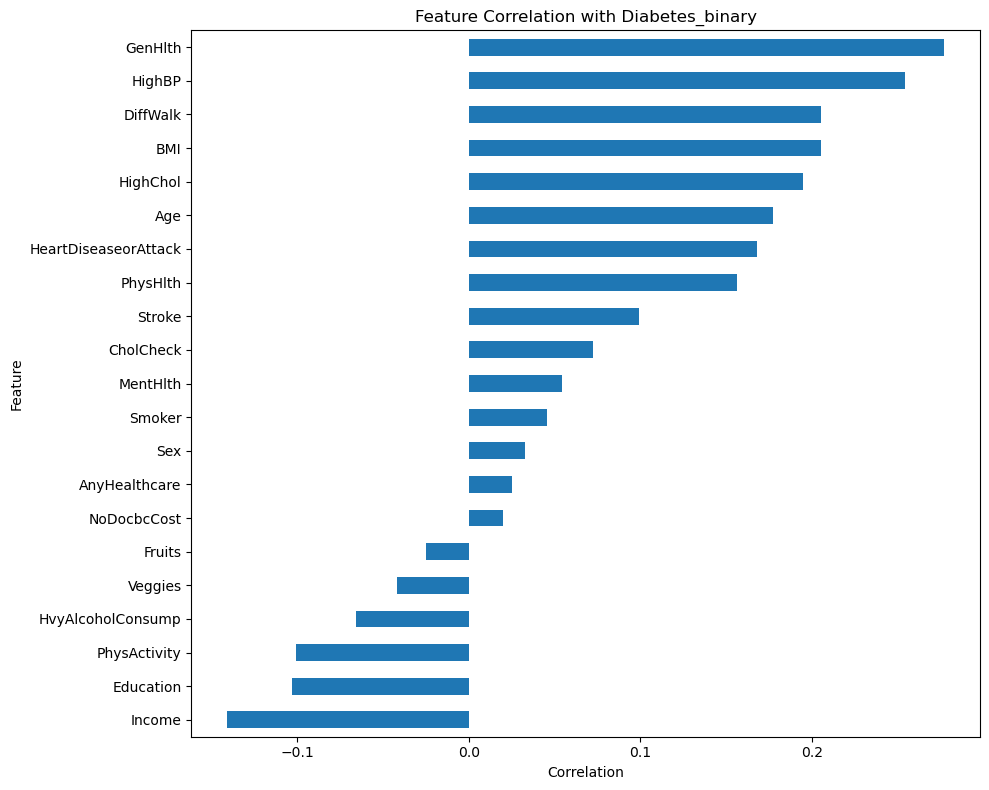

In [19]:
# Plot feature correlations with target

plt.figure(figsize=(10, 8))

target_correlations.sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Diabetes_binary")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

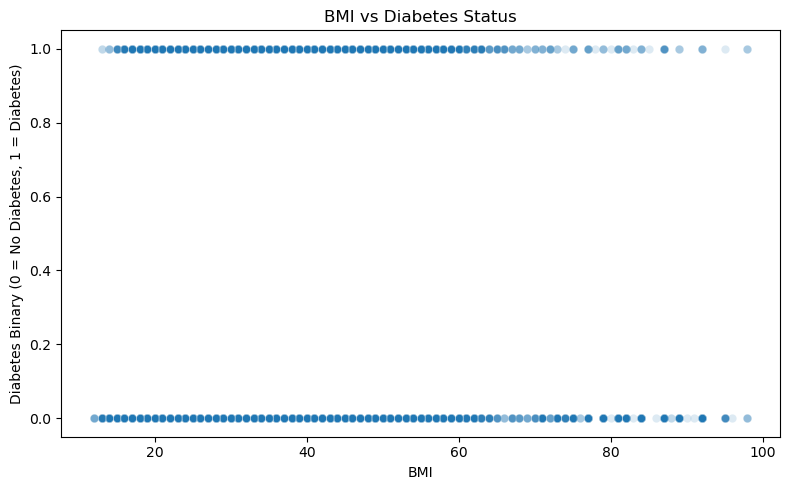

In [20]:
# ============================================================
# 18. BMI VS DIABETES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="BMI",
    y="Diabetes_binary",
    alpha=0.15
)

plt.title("BMI vs Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")

plt.tight_layout()
plt.show()

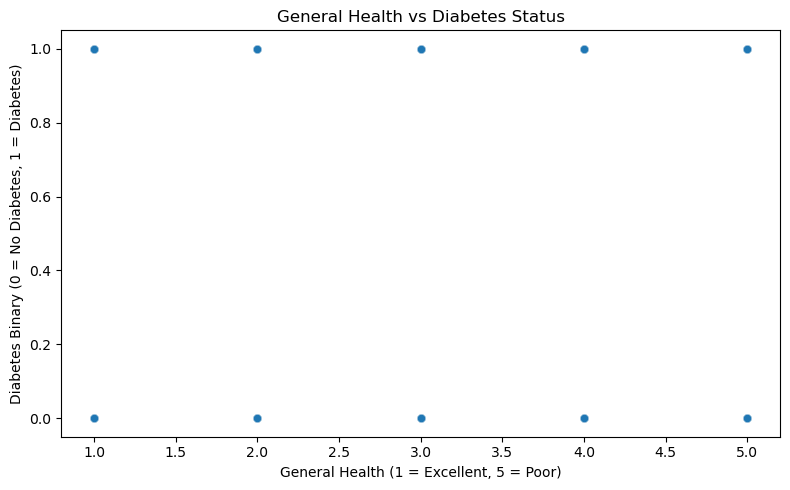

In [21]:
# ============================================================
# 19. GENERAL HEALTH VS DIABETES
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="GenHlth",
    y="Diabetes_binary",
    alpha=0.15
)

plt.title("General Health vs Diabetes Status")
plt.xlabel("General Health (1 = Excellent, 5 = Poor)")
plt.ylabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")

plt.tight_layout()
plt.show()


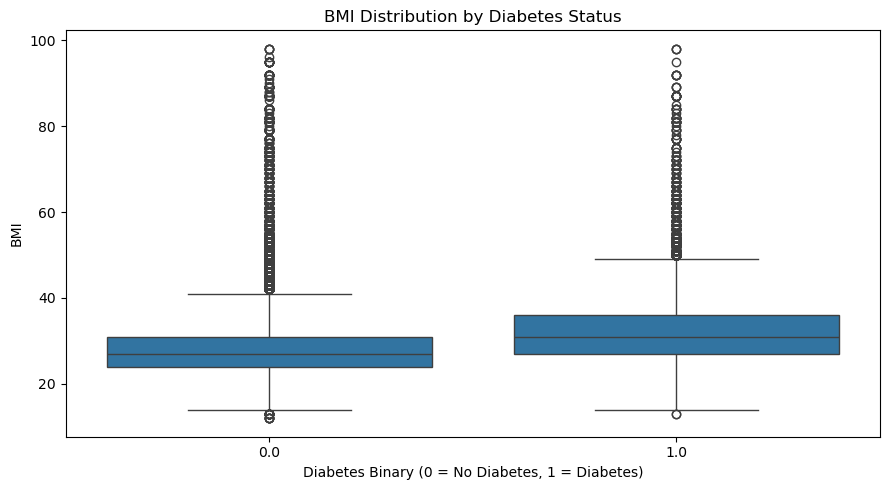

In [22]:
# ============================================================
# 20. BMI DISTRIBUTION BY DIABETES STATUS
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="BMI"
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

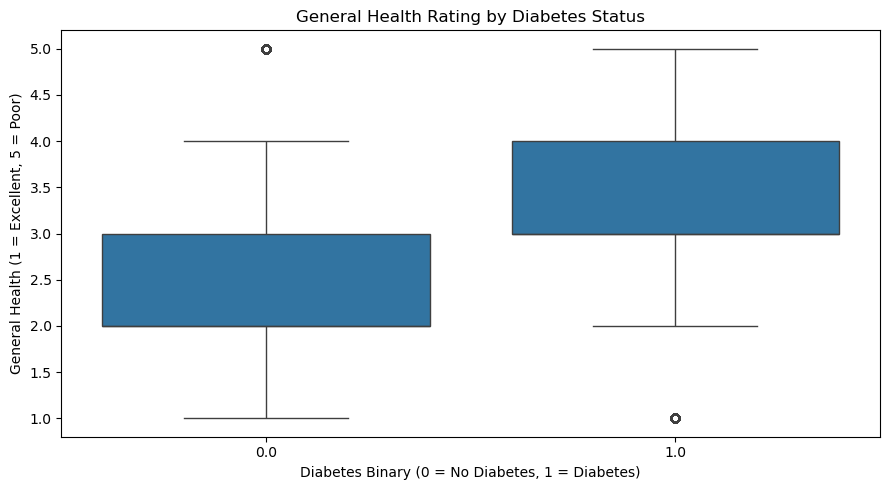

In [24]:
# ============================================================
# 21. GENERAL HEALTH BY DIABETES STATUS
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="GenHlth"
)

plt.title("General Health Rating by Diabetes Status")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("General Health (1 = Excellent, 5 = Poor)")

plt.tight_layout()
plt.show()

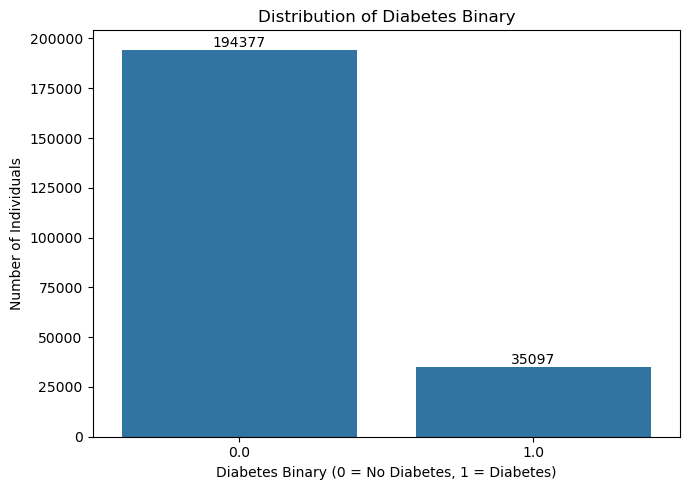

In [25]:
 # ============================================================
# 22. FINAL TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title("Distribution of Diabetes Binary")
plt.xlabel("Diabetes Binary (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Individuals")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()
 
 

### Observation

The target variable `Diabetes_binary` is imbalanced, with substantially more observations belonging to class 0 (no diabetes) than class 1 (diabetes). Therefore, accuracy alone may not fully represent model performance. Precision, recall, weighted F1-score, and the confusion matrix will also be considered during model evaluation.

# 3. DATA PREPROCESSING

In this section, the target variable is separated from the predictor variables. The dataset will then be split into training and testing sets using stratification to preserve the class distribution.

In [26]:
# ============================================================
# 23. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (229474, 21)
Target shape: (229474,)

Feature columns:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [27]:
# ============================================================
# 24. STRATIFIED TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (183579, 21)
y_train: (183579,)

Testing set:
X_test: (45895, 21)
y_test: (45895,)


In [28]:
# ============================================================
# 25. VERIFY CLASS DISTRIBUTION AFTER SPLIT
# ============================================================

print("Training target distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Training target distribution:
Diabetes_binary
0.0    84.705222
1.0    15.294778
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_binary
0.0    84.706395
1.0    15.293605
Name: proportion, dtype: float64


In [29]:
# ============================================================
# 26. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (183579, 21)
Scaled testing data shape: (45895, 21)


In [30]:
# ============================================================
# 27. VERIFY STANDARDIZATION
# ============================================================

print("Training feature means:")
print(np.mean(X_train_scaled, axis=0))

print("\nTraining feature standard deviations:")
print(np.std(X_train_scaled, axis=0))

Training feature means:
[ 1.33609701e-16  7.38491625e-17  9.36661285e-18 -2.56227178e-16
 -6.53340599e-17 -1.22307837e-17  4.08724924e-17 -2.03588362e-17
 -1.20295177e-16 -4.35818433e-17 -5.97605382e-17  1.03110151e-16
 -9.28920283e-19  5.35677363e-17  5.00068752e-17  3.01899092e-17
  1.09922233e-17  1.02181231e-17  1.05509862e-16 -3.31160081e-16
 -1.34228981e-16]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# 4. CLASSIFICATION MODELS

## 4.1 Logistic Regression

Logistic Regression is used as the baseline classification model. It estimates the probability that an observation belongs to the diabetes class and converts this probability into a binary prediction.

In [31]:
# ============================================================
# 28. LOGISTIC REGRESSION - BASELINE MODEL
# ============================================================

logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Predicted probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [32]:
X_train_scaled
X_test_scaled

array([[-0.91206897, -0.88909538,  0.20517645, ...,  0.94385728,
         0.02070903,  1.00785896],
       [-0.91206897, -0.88909538, -4.87385369, ..., -2.29188489,
         1.02779319, -0.903809  ],
       [ 1.09640832,  1.12473873,  0.20517645, ...,  1.59100571,
        -0.98637513,  0.05202498],
       ...,
       [ 1.09640832, -0.88909538,  0.20517645, ..., -0.67401381,
        -0.98637513,  1.00785896],
       [-0.91206897, -0.88909538,  0.20517645, ..., -0.35043959,
        -0.98637513,  1.00785896],
       [ 1.09640832,  1.12473873,  0.20517645, ...,  0.62028306,
         0.02070903,  0.52994197]], shape=(45895, 21))

In [34]:
# ============================================================
# 29. LOGISTIC REGRESSION - EVALUATION
# ============================================================

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")

Accuracy : 0.8505
Precision: 0.8150
Recall   : 0.8505
F1 Score : 0.8135
ROC-AUC  : 0.8102


In [36]:
# ============================================================
# FEATURE ENGINEERING - BMI × AGE INTERACTION
# ============================================================

df["BMI_Age_Interaction"] = df["BMI"] * df["Age"]

print("Feature engineered successfully!")
print(df[["BMI", "Age", "BMI_Age_Interaction"]].head())

Feature engineered successfully!
    BMI   Age  BMI_Age_Interaction
0  40.0   9.0                360.0
1  25.0   7.0                175.0
2  28.0   9.0                252.0
3  27.0  11.0                297.0
4  24.0  11.0                264.0


In [37]:
# ============================================================
# 3.1 UPDATED FEATURE-TARGET SPLIT
# ============================================================

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (229474, 22)
Target: (229474,)


In [38]:
# ============================================================
# 3.2 UPDATED TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (183579, 22)
X_test : (45895, 22)
y_train: (183579,)
y_test : (45895,)


In [39]:
# ============================================================
# 3.3 UPDATED FEATURE SCALING
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training shape: (183579, 22)
Scaled testing shape : (45895, 22)


In [40]:
# ============================================================
# 4.1 LOGISTIC REGRESSION - TRAINING
# ============================================================

logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [41]:
# ============================================================
# 4.2 LOGISTIC REGRESSION - EVALUATION
# ============================================================

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1 Score : {f1_logistic:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic:.4f}")

Accuracy : 0.8514
Precision: 0.8173
Recall   : 0.8514
F1 Score : 0.8158
ROC-AUC  : 0.8117


In [42]:
# ============================================================
# 4.3 LOGISTIC REGRESSION - CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Diabetes", "Diabetes"]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.87      0.98      0.92     38876
    Diabetes       0.55      0.16      0.25      7019

    accuracy                           0.85     45895
   macro avg       0.71      0.57      0.59     45895
weighted avg       0.82      0.85      0.82     45895



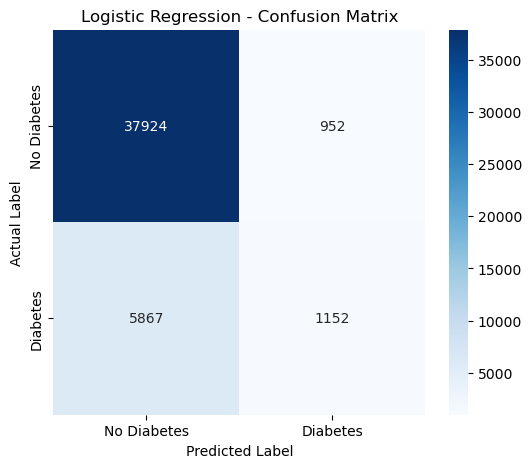

In [43]:
# ============================================================
# 4.4 LOGISTIC REGRESSION - CONFUSION MATRIX
# ============================================================

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Algorithm 2 — K-Nearest Neighbors (KNN).

In [44]:
# ============================================================
# 5.1 KNN - TRAINING SAMPLE FOR TUNING
# ============================================================

X_knn_tune, _, y_knn_tune, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("KNN tuning sample:", X_knn_tune.shape)
print("KNN tuning target:", y_knn_tune.shape)

KNN tuning sample: (30000, 22)
KNN tuning target: (30000,)


In [45]:
# ============================================================
# 5.2 KNN - TUNING NUMBER OF NEIGHBORS
# ============================================================

k_values = [3, 5, 7, 9, 11]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_knn_tune, y_knn_tune)

    y_pred_tune = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_tune)
    f1 = f1_score(y_test, y_pred_tune, average="weighted")

    knn_results.append({
        "K": k,
        "Accuracy": accuracy,
        "Weighted F1": f1
    })

knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)

,K,Accuracy,Weighted F1
0,3,0.817475,0.800722
1,5,0.831049,0.806340
2,7,0.838370,0.809288
3,9,0.841878,0.808141
4,11,0.843883,0.806568


In [46]:
# ============================================================
# 5.3 KNN - FINAL MODEL
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    metric="euclidean"
)

knn_model.fit(X_knn_tune, y_knn_tune)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN model trained successfully!")
print("Selected K:", 7)
print("Distance metric: Euclidean")

KNN model trained successfully!
Selected K: 7
Distance metric: Euclidean


In [47]:
# ============================================================
# 5.4 KNN - EVALUATION
# ============================================================

accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

# KNN does not provide predict_proba unless configured differently;
# use probabilities for ROC-AUC
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_knn = roc_auc_score(
    y_test,
    y_prob_knn
)

print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn:.4f}")

Accuracy : 0.8384
Precision: 0.7998
Recall   : 0.8384
F1 Score : 0.8093
ROC-AUC  : 0.7270


In [48]:
# ============================================================
# 5.5 KNN - CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["No Diabetes", "Diabetes"]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.87      0.96      0.91     38876
    Diabetes       0.43      0.18      0.26      7019

    accuracy                           0.84     45895
   macro avg       0.65      0.57      0.58     45895
weighted avg       0.80      0.84      0.81     45895



In [49]:
# ============================================================
# 5.6 KNN - ROC-AUC
# ============================================================

y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_knn = roc_auc_score(
    y_test,
    y_prob_knn
)

print(f"ROC-AUC: {roc_auc_knn:.4f}")

ROC-AUC: 0.7270


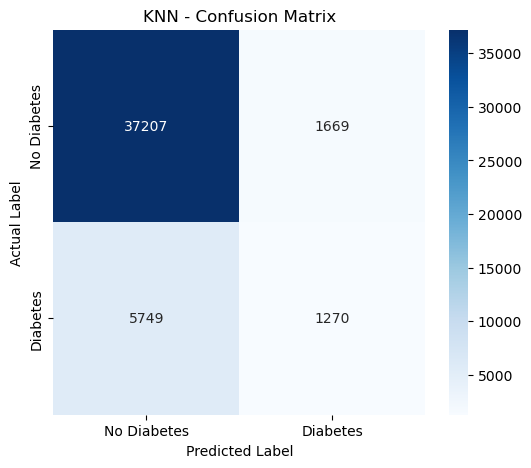

In [50]:
# ============================================================
# 5.7 KNN - CONFUSION MATRIX
# ============================================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Algorithm 3 — Gaussian Naive Bayes.

In [51]:
# ============================================================
# 6.1 GAUSSIAN NAIVE BAYES - TRAINING
# ============================================================

gnb_model = GaussianNB()

gnb_model.fit(X_train_scaled, y_train)

y_pred_gnb = gnb_model.predict(X_test_scaled)
y_prob_gnb = gnb_model.predict_proba(X_test_scaled)[:, 1]

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [52]:
# ============================================================
# 6.2 GAUSSIAN NAIVE BAYES - EVALUATION
# ============================================================

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)

precision_gnb = precision_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)

recall_gnb = recall_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)

f1_gnb = f1_score(
    y_test,
    y_pred_gnb,
    average="weighted"
)

roc_auc_gnb = roc_auc_score(
    y_test,
    y_prob_gnb
)

print(f"Accuracy : {accuracy_gnb:.4f}")
print(f"Precision: {precision_gnb:.4f}")
print(f"Recall   : {recall_gnb:.4f}")
print(f"F1 Score : {f1_gnb:.4f}")
print(f"ROC-AUC  : {roc_auc_gnb:.4f}")

Accuracy : 0.7549
Precision: 0.8296
Recall   : 0.7549
F1 Score : 0.7811
ROC-AUC  : 0.7768


In [53]:
# ============================================================
# 6.3 GAUSSIAN NAIVE BAYES - CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_gnb,
        target_names=["No Diabetes", "Diabetes"]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.92      0.78      0.84     38876
    Diabetes       0.34      0.62      0.44      7019

    accuracy                           0.75     45895
   macro avg       0.63      0.70      0.64     45895
weighted avg       0.83      0.75      0.78     45895



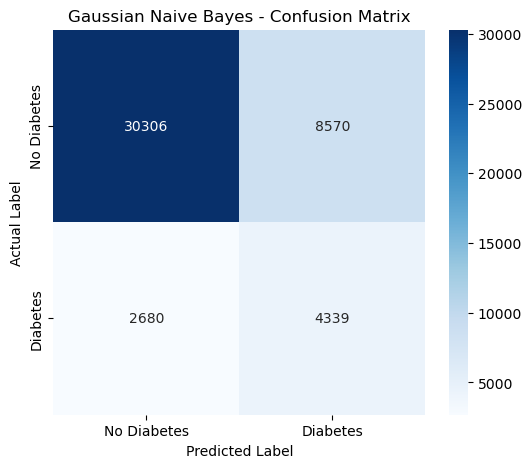

In [54]:
# ============================================================
# 6.4 GAUSSIAN NAIVE BAYES - CONFUSION MATRIX
# ============================================================

cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

Algorithm 4 — Decision Tree Classifier

In [55]:
# ============================================================
# 7.1 DECISION TREE - TUNING MAX DEPTH
# ============================================================

depth_values = [3, 5, 7, 10, 15, 20]
dt_results = []

for depth in depth_values:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    dt.fit(X_train, y_train)

    y_pred_dt_tune = dt.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred_dt_tune)
    f1 = f1_score(
        y_test,
        y_pred_dt_tune,
        average="weighted"
    )

    dt_results.append({
        "Max Depth": depth,
        "Accuracy": accuracy,
        "Weighted F1": f1
    })

dt_results_df = pd.DataFrame(dt_results)

display(dt_results_df)

,Max Depth,Accuracy,Weighted F1
0,3,0.847064,0.776927
1,5,0.852184,0.803903
2,7,0.852598,0.800333
3,10,0.851661,0.811535
4,15,0.832073,0.810701
5,20,0.804576,0.797076


In [56]:
# ============================================================
# 7.2 DECISION TREE - FINAL MODEL
# ============================================================

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully!")
print("Selected max_depth:", 10)

Decision Tree model trained successfully!
Selected max_depth: 10


In [57]:
# ============================================================
# 7.3 DECISION TREE - EVALUATION
# ============================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Accuracy : 0.8517
Precision: 0.8168
Recall   : 0.8517
F1 Score : 0.8115
ROC-AUC  : 0.7986


In [58]:
# ============================================================
# 7.4 DECISION TREE - CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["No Diabetes", "Diabetes"]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     38876
    Diabetes       0.56      0.14      0.22      7019

    accuracy                           0.85     45895
   macro avg       0.71      0.56      0.57     45895
weighted avg       0.82      0.85      0.81     45895



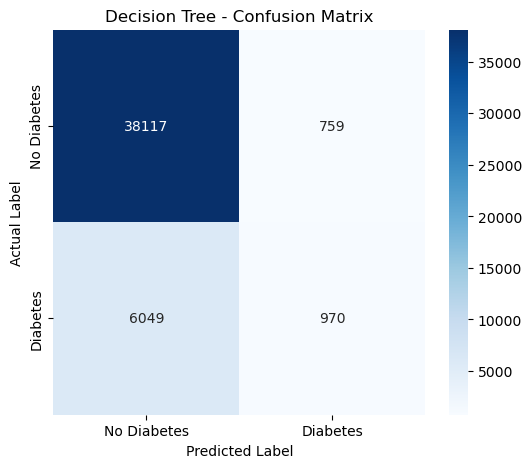

In [59]:
# ============================================================
# 7.5 DECISION TREE - CONFUSION MATRIX
# ============================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

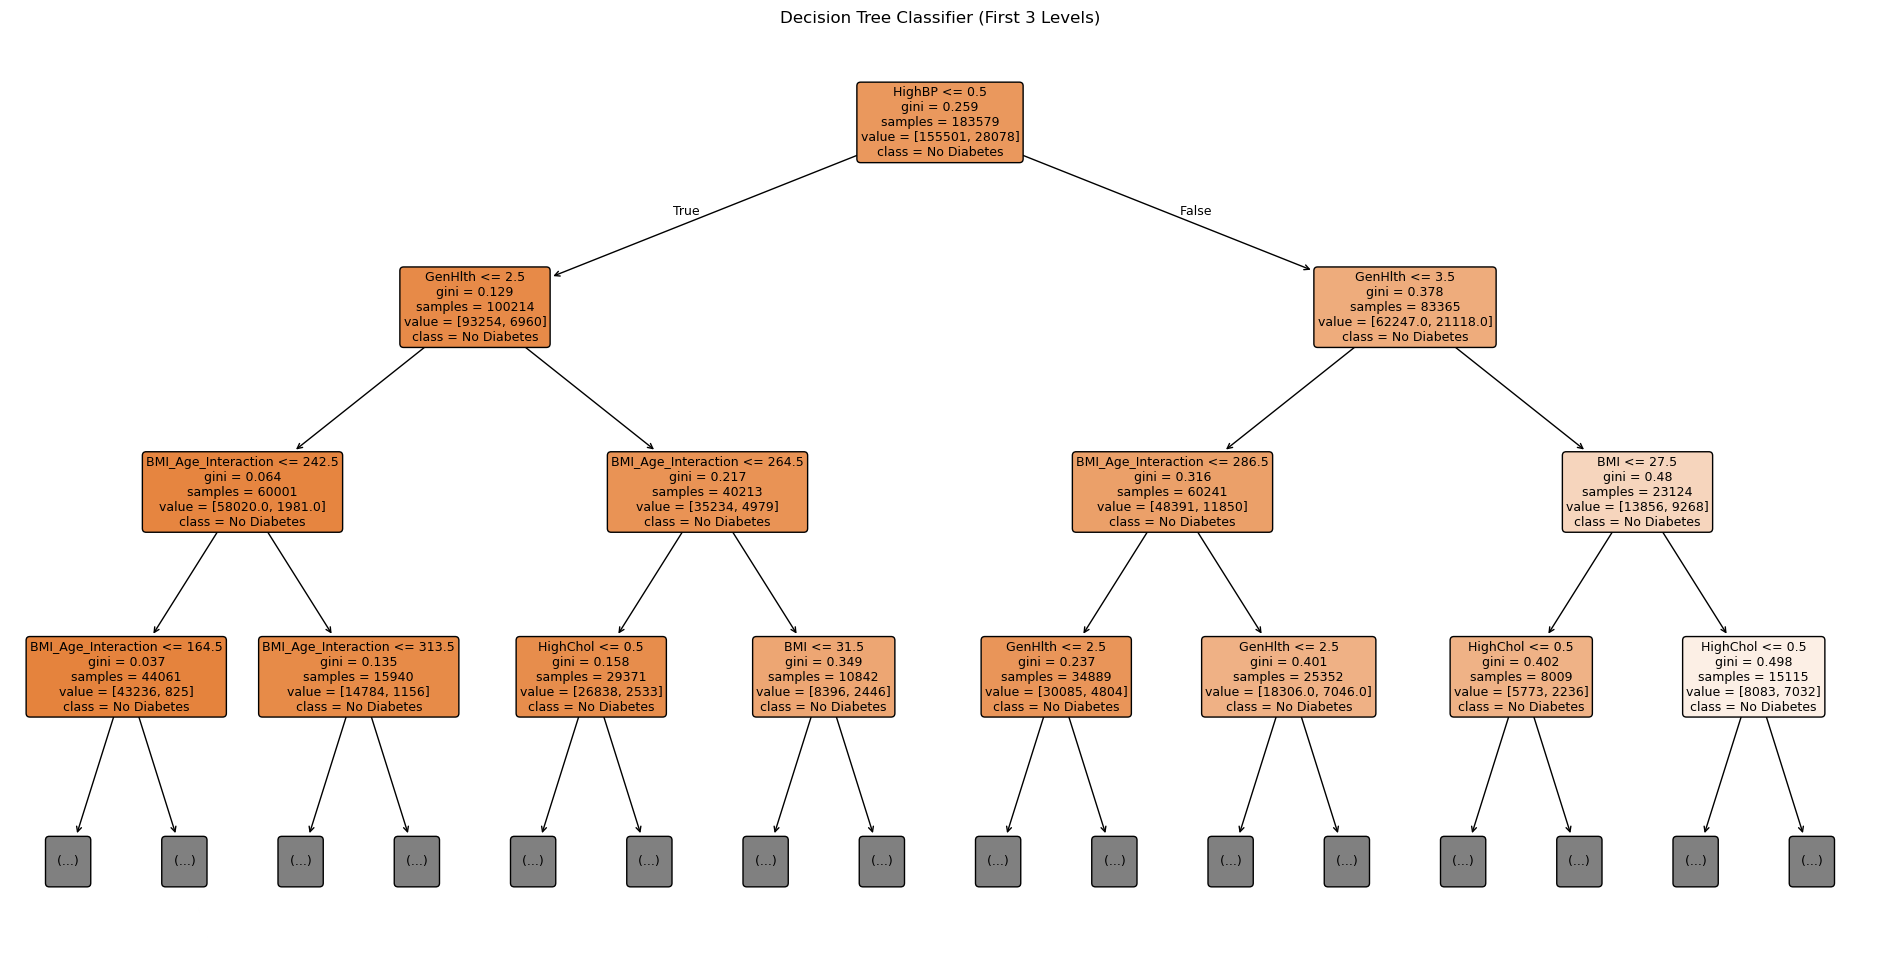

In [60]:
# ============================================================
# 7.6 DECISION TREE - VISUALIZATION
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Classifier (First 3 Levels)")
plt.show()


Algorithm 5 — SVC

In [61]:
# ============================================================
# 8.1 SVC - TRAINING SAMPLE
# ============================================================

X_svc_tune, _, y_svc_tune, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=10000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("SVC tuning sample:", X_svc_tune.shape)
print("SVC tuning target:", y_svc_tune.shape)

SVC tuning sample: (10000, 22)
SVC tuning target: (10000,)


In [62]:
# ============================================================
# 8.2 SVC - HYPERPARAMETER TUNING
# ============================================================

svc_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svc_grid = GridSearchCV(
    estimator=SVC(
        random_state=RANDOM_STATE,
        probability=True
    ),
    param_grid=svc_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

svc_grid.fit(X_svc_tune, y_svc_tune)

print("Best SVC parameters:", svc_grid.best_params_)
print("Best weighted F1:", round(svc_grid.best_score_, 4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVC parameters: {'C': 10, 'kernel': 'rbf'}
Best weighted F1: 0.8065


In [63]:
# ============================================================
# 8.3 SVC - FINAL MODEL
# ============================================================

svc_model = svc_grid.best_estimator_

# Predict on the untouched test set
y_pred_svc = svc_model.predict(X_test_scaled)
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

print("SVC model trained successfully!")
print("Selected C:", svc_grid.best_params_["C"])
print("Selected kernel:", svc_grid.best_params_["kernel"])

SVC model trained successfully!
Selected C: 10
Selected kernel: rbf


In [64]:
# ============================================================
# 8.4 SVC - EVALUATION
# ============================================================

accuracy_svc = accuracy_score(y_test, y_pred_svc)

precision_svc = precision_score(
    y_test,
    y_pred_svc,
    average="weighted"
)

recall_svc = recall_score(
    y_test,
    y_pred_svc,
    average="weighted"
)

f1_svc = f1_score(
    y_test,
    y_pred_svc,
    average="weighted"
)

roc_auc_svc = roc_auc_score(
    y_test,
    y_prob_svc
)

print(f"Accuracy : {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall   : {recall_svc:.4f}")
print(f"F1 Score : {f1_svc:.4f}")
print(f"ROC-AUC  : {roc_auc_svc:.4f}")

Accuracy : 0.8379
Precision: 0.7994
Recall   : 0.8379
F1 Score : 0.8091
ROC-AUC  : 0.6985


In [65]:
# ============================================================
# 8.5 SVC - CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_svc,
        target_names=["No Diabetes", "Diabetes"]
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.87      0.96      0.91     38876
    Diabetes       0.43      0.18      0.26      7019

    accuracy                           0.84     45895
   macro avg       0.65      0.57      0.58     45895
weighted avg       0.80      0.84      0.81     45895



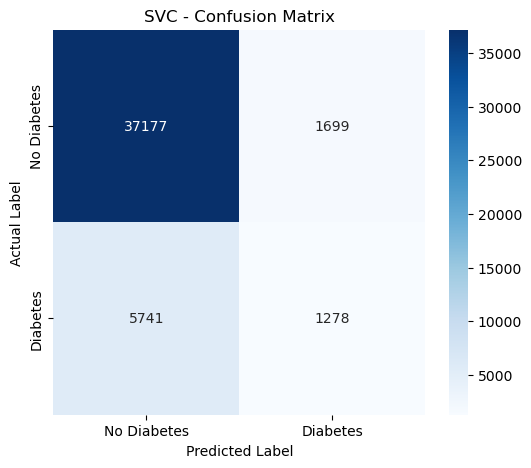

In [66]:
# ============================================================
# 8.6 SVC - CONFUSION MATRIX
# ============================================================

cm_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("SVC - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

preliminary comparison table

In [67]:
# ============================================================
# 9. PART A - PRELIMINARY MODEL COMPARISON
# ============================================================

models = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "KNN (K=7)": (y_pred_knn, y_prob_knn),
    "Gaussian Naive Bayes": (y_pred_gnb, y_prob_gnb),
    "Decision Tree (Depth=10)": (y_pred_dt, y_prob_dt),
    "SVC (C=10, RBF)": (y_pred_svc, y_prob_svc)
}

comparison_results = []

for model_name, (y_pred, y_prob) in models.items():
    comparison_results.append({
        "Algorithm": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Weighted)": precision_score(
            y_test, y_pred, average="weighted"
        ),
        "Recall (Weighted)": recall_score(
            y_test, y_pred, average="weighted"
        ),
        "F1-Score (Weighted)": f1_score(
            y_test, y_pred, average="weighted"
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_results)

display(
    comparison_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision (Weighted)": "{:.4f}",
        "Recall (Weighted)": "{:.4f}",
        "F1-Score (Weighted)": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Algorithm,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),ROC-AUC
0,Logistic Regression,0.8514,0.8173,0.8514,0.8158,0.8117
1,KNN (K=7),0.8384,0.7998,0.8384,0.8093,0.7270
2,Gaussian Naive Bayes,0.7549,0.8296,0.7549,0.7811,0.7768
3,Decision Tree (Depth=10),0.8517,0.8168,0.8517,0.8115,0.7986
4,"SVC (C=10, RBF)",0.8379,0.7994,0.8379,0.8091,0.6985


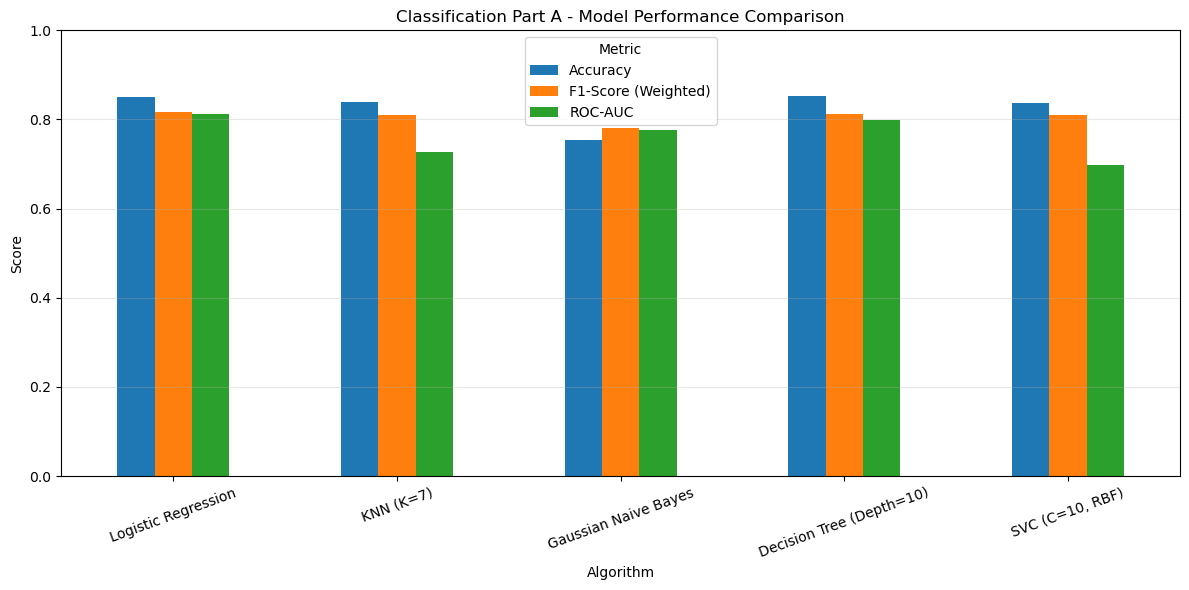

In [68]:
# ============================================================
# 9.1 PART A - MODEL COMPARISON VISUALIZATION
# ============================================================

comparison_plot = comparison_df.set_index("Algorithm")[
    ["Accuracy", "F1-Score (Weighted)", "ROC-AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Part A - Model Performance Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Part A Preliminary Comparison - Observations

The five classification algorithms were compared using Accuracy, Weighted F1-Score, and ROC-AUC.

- Decision Tree achieved the highest accuracy (85.17%), closely followed by Logistic Regression (85.14%).
- Logistic Regression achieved the highest Weighted F1-Score (0.8158) and ROC-AUC (0.8117), indicating the strongest overall performance among the five models.
- KNN and SVC achieved similar accuracy levels, but their ROC-AUC scores were lower than Logistic Regression.
- Gaussian Naive Bayes produced the lowest accuracy (75.49%) and Weighted F1-Score (0.7811), although its ROC-AUC was 0.7768.
- The models generally performed much better on the No Diabetes class than the Diabetes class. This is mainly associated with the class imbalance in the dataset.
- Therefore, accuracy alone is not sufficient for evaluating these models. Weighted F1-Score and ROC-AUC provide additional information for model comparison.

Logistic Regression coefficient interpretation

In [69]:
# ============================================================
# 9.2 LOGISTIC REGRESSION - COEFFICIENT INTERPRETATION
# ============================================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0],
    "Odds_Ratio": np.exp(logistic_model.coef_[0])
})

coef_df = coef_df.sort_values("Odds_Ratio", ascending=False)

display(
    coef_df.style.format({
        "Coefficient": "{:.4f}",
        "Odds_Ratio": "{:.4f}"
    })
)

,Feature,Coefficient,Odds_Ratio
13,GenHlth,0.5382,1.7129
21,BMI_Age_Interaction,0.5157,1.6749
0,HighBP,0.3649,1.4404
1,HighChol,0.2779,1.3204
2,CholCheck,0.2507,1.2849
17,Sex,0.1279,1.1365
3,BMI,0.1132,1.1198
6,HeartDiseaseorAttack,0.0659,1.0681
16,DiffWalk,0.0425,1.0434
5,Stroke,0.0275,1.0279


### Logistic Regression - Coefficient and Odds Ratio Interpretation

Logistic Regression coefficients were examined using odds ratios to understand the direction and relative strength of feature associations with the predicted positive class.

- GenHlth had the largest positive coefficient (0.5382), with an odds ratio of 1.7129.
- The engineered BMI_Age_Interaction feature also showed a strong positive coefficient (0.5157), with an odds ratio of 1.6749.
- HighBP (OR = 1.4404) and HighChol (OR = 1.3204) were also among the strongest positive predictors.
- HvyAlcoholConsump had the strongest negative coefficient (−0.1913), corresponding to an odds ratio of 0.8259.
- Age (OR = 0.8999) and Income (OR = 0.9074) also had negative coefficients.

Since the input features were standardized before training, the odds ratios for continuous and ordinal variables represent the change in predicted odds associated with a one-standard-deviation increase in the feature, while holding the other variables constant.

These coefficients describe associations learned by the model and should not be interpreted as causal relationships.

KNN — distance metric discussion + confusion matrix.

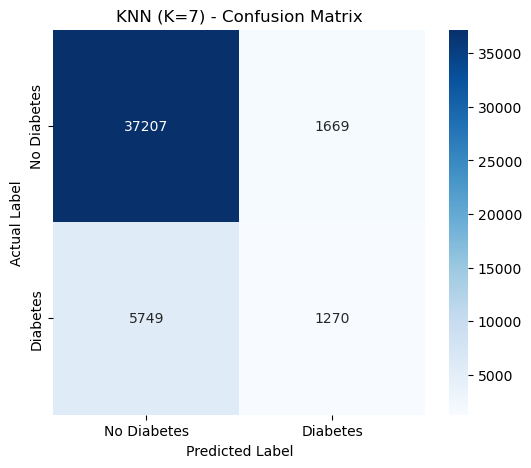

In [70]:
# ============================================================
# KNN - CONFUSION MATRIX
# ============================================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("KNN (K=7) - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


### KNN - Distance Metric Discussion

K-Nearest Neighbors classifies a sample based on the classes of its nearest training samples. In this study, Euclidean distance was used with K=7.

Feature scaling was important because KNN is distance-based. Without scaling, features with larger numerical ranges could dominate the distance calculation.

Euclidean distance measures the straight-line distance between observations, while Manhattan distance measures the sum of absolute differences across features. Euclidean distance was selected for this experiment because it is commonly used for continuous and standardized feature spaces.

The value K=7 was selected based on the highest Weighted F1-Score among the tested K values (3, 5, 7, 9, and 11).

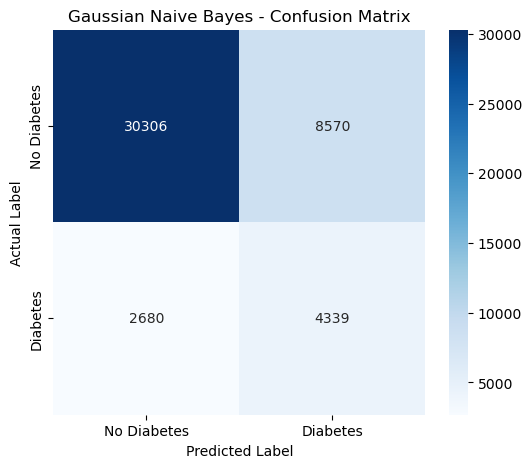

In [71]:
# ============================================================
# GAUSSIAN NAIVE BAYES - CONFUSION MATRIX
# ============================================================

cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### Gaussian Naive Bayes - Conditional Independence

Gaussian Naive Bayes assumes that the input features are conditionally independent given the target class. In other words, once the diabetes class is known, the model assumes that the features contribute independently to the probability of that class.

This assumption is strong for this dataset because several health-related variables can be correlated with one another. Despite this limitation, Gaussian Naive Bayes achieved a Diabetes recall of approximately 62%, which was considerably higher than the other Part A models.

However, this came with a higher number of false positives, resulting in lower overall accuracy (75.49%) and Weighted F1-Score (0.7811).

cross-validation for the two best Part A models: Logistic Regression and Decision Tree.

In [72]:
# ============================================================
# 10. CROSS-VALIDATION - BEST PART A MODELS
# ============================================================

from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# Logistic Regression pipeline
logistic_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Decision Tree
dt_cv_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=RANDOM_STATE
)

# Evaluation metrics
cv_scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
    "roc_auc": "roc_auc"
}

# Logistic Regression CV
logistic_cv = cross_validate(
    logistic_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring=cv_scoring,
    n_jobs=-1
)

# Decision Tree CV
dt_cv = cross_validate(
    dt_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring=cv_scoring,
    n_jobs=-1
)

# Create summary table
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree (Depth=10)"
    ],
    "CV Accuracy Mean": [
        logistic_cv["test_accuracy"].mean(),
        dt_cv["test_accuracy"].mean()
    ],
    "CV Accuracy Std": [
        logistic_cv["test_accuracy"].std(),
        dt_cv["test_accuracy"].std()
    ],
    "CV Weighted F1 Mean": [
        logistic_cv["test_f1_weighted"].mean(),
        dt_cv["test_f1_weighted"].mean()
    ],
    "CV Weighted F1 Std": [
        logistic_cv["test_f1_weighted"].std(),
        dt_cv["test_f1_weighted"].std()
    ],
    "CV ROC-AUC Mean": [
        logistic_cv["test_roc_auc"].mean(),
        dt_cv["test_roc_auc"].mean()
    ]
})

display(
    cv_results.style.format({
        "CV Accuracy Mean": "{:.4f}",
        "CV Accuracy Std": "{:.4f}",
        "CV Weighted F1 Mean": "{:.4f}",
        "CV Weighted F1 Std": "{:.4f}",
        "CV ROC-AUC Mean": "{:.4f}"
    })
)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Weighted F1 Mean,CV Weighted F1 Std,CV ROC-AUC Mean
0,Logistic Regression,0.8509,0.0007,0.8139,0.0016,0.8081
1,Decision Tree (Depth=10),0.8494,0.0005,0.8113,0.0017,0.7917


### Cross-Validation Results

Five-fold cross-validation was performed on the training data for Logistic Regression and Decision Tree, the two strongest Part A models.

- Logistic Regression achieved a mean CV accuracy of 0.8509 and a mean Weighted F1-Score of 0.8139.
- Decision Tree achieved a mean CV accuracy of 0.8494 and a mean Weighted F1-Score of 0.8113.
- Logistic Regression also achieved the higher mean CV ROC-AUC of 0.8081 compared with 0.7917 for the Decision Tree.
- The small standard deviations indicate that both models produced stable results across the five folds.
- Overall, Logistic Regression showed slightly better and more consistent generalization performance than the Decision Tree.

Previously, the depth was selected using the test set. This time, we'll select max_depth using 5-fold cross-validation on the training data only. The test set will remain untouched.

In [73]:
# ============================================================
# 10.1 DECISION TREE - PROPER HYPERPARAMETER TUNING
# ============================================================

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    param_grid=dt_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

# IMPORTANT: tuning is performed only on training data
dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV Weighted F1:", round(dt_grid.best_score_, 4))

dt_cv_results = pd.DataFrame(dt_grid.cv_results_)[
    ["param_max_depth", "mean_test_score", "std_test_score"]
]

dt_cv_results.columns = [
    "Max Depth",
    "Mean CV Weighted F1",
    "Std CV Weighted F1"
]

display(
    dt_cv_results.style.format({
        "Mean CV Weighted F1": "{:.4f}",
        "Std CV Weighted F1": "{:.4f}"
    })
)

Best Parameters: {'max_depth': 10}
Best CV Weighted F1: 0.8113


,Max Depth,Mean CV Weighted F1,Std CV Weighted F1
0,3,0.7769,0.0000
1,5,0.8029,0.0012
2,7,0.8023,0.0047
3,10,0.8113,0.0017
4,15,0.8068,0.0015
5,20,0.7925,0.0010


In [74]:
# ============================================================
# 10.2 FINAL DECISION TREE AFTER PROPER CV TUNING
# ============================================================

best_dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=RANDOM_STATE
)

# Train only on training data
best_dt_model.fit(X_train, y_train)

# Final evaluation on untouched test data
y_pred_dt_final = best_dt_model.predict(X_test)
y_prob_dt_final = best_dt_model.predict_proba(X_test)[:, 1]

print("Final Decision Tree Results")
print("-" * 40)

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_dt_final), 4))

print("Weighted Precision:",
      round(precision_score(
          y_test, y_pred_dt_final, average="weighted"
      ), 4))

print("Weighted Recall:",
      round(recall_score(
          y_test, y_pred_dt_final, average="weighted"
      ), 4))

print("Weighted F1:",
      round(f1_score(
          y_test, y_pred_dt_final, average="weighted"
      ), 4))

print("ROC-AUC:",
      round(roc_auc_score(
          y_test, y_prob_dt_final
      ), 4))

Final Decision Tree Results
----------------------------------------
Accuracy: 0.8517
Weighted Precision: 0.8168
Weighted Recall: 0.8517
Weighted F1: 0.8115
ROC-AUC: 0.7986


In [75]:
# ============================================================
# 10.3 KNN - PROPER CROSS-VALIDATED TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "metric": ["euclidean"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Tune ONLY on the 30,000-row training sample
knn_grid.fit(X_knn_tune, y_knn_tune)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV Weighted F1:", round(knn_grid.best_score_, 4))

knn_cv_results = pd.DataFrame(knn_grid.cv_results_)[
    ["param_n_neighbors", "mean_test_score", "std_test_score"]
]

knn_cv_results.columns = [
    "K",
    "Mean CV Weighted F1",
    "Std CV Weighted F1"
]

display(
    knn_cv_results.style.format({
        "Mean CV Weighted F1": "{:.4f}",
        "Std CV Weighted F1": "{:.4f}"
    })
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7}
Best CV Weighted F1: 0.8051


,K,Mean CV Weighted F1,Std CV Weighted F1
0,3,0.8004,0.0017
1,5,0.8038,0.0024
2,7,0.8051,0.0019
3,9,0.8046,0.0032
4,11,0.8030,0.0026


### KNN Cross-Validated Tuning

KNN hyperparameter tuning was performed using five-fold cross-validation on a stratified 30,000-sample subset of the training data.

The tested values of K were 3, 5, 7, 9, and 11 using Euclidean distance.

K=7 achieved the highest mean CV Weighted F1-Score of 0.8051 with a standard deviation of 0.0019. Therefore, K=7 was selected as the final KNN configuration.

The relatively small standard deviation indicates stable performance across the five folds.

In [76]:
# ============================================================
# 10.4 FINAL KNN AFTER PROPER CV TUNING
# ============================================================

best_knn_model = KNeighborsClassifier(
    n_neighbors=7,
    metric="euclidean"
)

# Train only on the tuning subset of training data
best_knn_model.fit(X_knn_tune, y_knn_tune)

# Final evaluation on untouched test data
y_pred_knn_final = best_knn_model.predict(X_test_scaled)
y_prob_knn_final = best_knn_model.predict_proba(X_test_scaled)[:, 1]

print("Final KNN Results")
print("-" * 40)

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_knn_final), 4))

print("Weighted Precision:",
      round(precision_score(
          y_test, y_pred_knn_final, average="weighted"
      ), 4))

print("Weighted Recall:",
      round(recall_score(
          y_test, y_pred_knn_final, average="weighted"
      ), 4))

print("Weighted F1:",
      round(f1_score(
          y_test, y_pred_knn_final, average="weighted"
      ), 4))

print("ROC-AUC:",
      round(roc_auc_score(
          y_test, y_prob_knn_final
      ), 4))

Final KNN Results
----------------------------------------
Accuracy: 0.8384
Weighted Precision: 0.7998
Weighted Recall: 0.8384
Weighted F1: 0.8093
ROC-AUC: 0.727
